# Fraud Detection in Internship Applications using Machine Learning

### Internship Task 3

**Intern:** Asma Yousaf

## Objective

The objective of this project is to identify suspicious internship applications by analyzing applicant behavior and detecting anomalies using machine learning algorithms.

This project uses:

- Exploratory Data Analysis (EDA)
- Isolation Forest
- K-Means Clustering

The detected anomalies can help organizations reduce fake applications and improve the recruitment process.

# Step 1: Import Required Libraries

Before starting the analysis, we import all the necessary Python libraries.

These libraries help us with:

- Reading the dataset
- Data manipulation
- Visualization
- Data preprocessing
- Machine Learning

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Step 2: Load the Dataset

The dataset is loaded into a Pandas DataFrame.

A DataFrame is a tabular data structure that allows us to easily manipulate and analyze data.

In [2]:
df = pd.read_csv("internship_applications_dataset.csv")

df.head()

,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,IP_Address,Device_ID,Submission_Date,Submission_Time,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly
0,APP0001,Allison Hill,allison.hill655@gmail.com,311419610,46048-5108603-3,22,Other,University of the Punjab,BS Computer Science,3.20,...,207.228.165.26,DEV-O36JWBWNUH,6/10/2026,18:00:13,8,Yes,No,No,UI/UX Intern,1
1,APP0002,Noah Rhodes,noah.rhodes827@gmail.com,374388982,80284-3094235-6,13,Other,UET Lahore,BS Artificial Intelligence,3.18,...,219.119.51.98,DEV-KWNNHJ7XVG,5/24/2026,18:27:02,347,Yes,Yes,No,Backend Developer Intern,1
2,APP0003,Angie Henderson,angie.henderson702@gmail.com,351938483,40021-1538552-5,26,Female,University of the Punjab,BS Data Science,3.75,...,68.71.126.191,DEV-UJV6OH9SDB,5/11/2026,15:30:03,336,Yes,Yes,Yes,Machine Learning Intern,0
3,APP0004,Daniel Wagner,daniel.wagner395@gmail.com,368852574,79352-5218028-8,20,Other,NED University Karachi,BS Computer Science,3.36,...,117.1.134.249,DEV-SG65KXVF1T,6/21/2026,11:48:49,1120,Yes,Yes,Yes,Business Analyst Intern,0
4,APP0005,Cristian Santos,cristian.santos900@gmail.com,345017343,17592-5041154-9,21,Male,NED University Karachi,BS Statistics,3.59,...,68.216.108.238,DEV-T0HL9XPSEI,6/2/2026,19:47:47,201,Yes,Yes,Yes,Machine Learning Intern,0


# Step 3: Dataset Overview

Before applying machine learning, it is important to understand the structure of the dataset.

In this step we will examine:

- Number of rows
- Number of columns
- Data types
- Missing values
- Statistical summary

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Application_ID       500 non-null    object 
 1   Applicant_Name       500 non-null    object 
 2   Email                500 non-null    object 
 3   Phone_Number         500 non-null    int64  
 4   CNIC                 500 non-null    object 
 5   Age                  500 non-null    int64  
 6   Gender               500 non-null    object 
 7   University           500 non-null    object 
 8   Degree               500 non-null    object 
 9   CGPA                 500 non-null    float64
 10  Experience_Years     500 non-null    float64
 11  Skills               500 non-null    object 
 12  City                 500 non-null    object 
 13  IP_Address           500 non-null    object 
 14  Device_ID            500 non-null    object 
 15  Submission_Date      500 non-null    obj

In [4]:
df.describe()

,Phone_Number,Age,CGPA,Experience_Years,Submission_Duration,Is_Injected_Anomaly
count,5.000000e+02,500.000000,500.000000,500.000000,500.000000,500.000000
mean,3.485133e+08,23.972000,3.022440,1.693200,645.954000,0.202000
std,2.876672e+07,6.038223,0.607712,2.299541,320.886835,0.401894
min,3.017388e+08,13.000000,-1.000000,0.000000,2.000000,0.000000
25%,3.247089e+08,21.000000,2.567500,0.700000,400.500000,0.000000
50%,3.459349e+08,23.000000,2.995000,1.400000,626.500000,0.000000
75%,3.743661e+08,26.000000,3.512500,2.300000,921.250000,0.000000
max,3.997671e+08,99.000000,4.800000,25.000000,1196.000000,1.000000


In [5]:
df.shape

(500, 23)

# Step 4: Check Missing Values

Missing values reduce model accuracy.

In this step we identify whether any column contains null values.

In [6]:
df.isnull().sum()

Application_ID         0
Applicant_Name         0
Email                  0
Phone_Number           0
CNIC                   0
Age                    0
Gender                 0
University             0
Degree                 0
CGPA                   0
Experience_Years       0
Skills                 0
City                   0
IP_Address             0
Device_ID              0
Submission_Date        0
Submission_Time        0
Submission_Duration    0
Resume_Uploaded        0
Email_Verified         0
Phone_Verified         0
Internship_Position    0
Is_Injected_Anomaly    0
dtype: int64

# Step 5: Duplicate Records Analysis

## Objective

Before applying machine learning models, it is important to identify duplicate records in the dataset.

In [8]:
duplicate_records = df.duplicated().sum()

print("Total Duplicate Records:", duplicate_records)

Total Duplicate Records: 0


### Observation

The dataset does not contain any completely duplicated records.

This indicates that each application is unique, and no duplicate rows need to be removed before proceeding with further analysis.

# Step 6: Detect Duplicate Email Addresses

In [9]:
duplicate_email = df[df["Email"].duplicated(keep=False)]

print("Total Duplicate Email Records:", len(duplicate_email))

duplicate_email.head()

Total Duplicate Email Records: 36


,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,IP_Address,Device_ID,Submission_Date,Submission_Time,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly
7,APP0008,Gina Moore,gina.moore766@gmail.com,351959074,16572-8999183-8,22,Male,Virtual University of Pakistan,BS Computer Science,3.65,...,146.126.20.159,DEV-CXULJYLJEX,6/14/2026,9:24:37,503,No,No,Yes,Machine Learning Intern,0
15,APP0016,Brian Ramirez,daniel.baker32@gmail.com,368030010,80545-4700025-7,23,Female,Punjab University College of IT,BS Statistics,2.25,...,145.13.42.165,DEV-P5GJLQM5K8,6/10/2026,22:19:02,438,Yes,Yes,Yes,Data Analytics Intern,1
22,APP0023,Ethan Adams,ethan.adams591@gmail.com,303939212,71669-9706768-7,24,Male,Bahauddin Zakariya University,MSc IT,3.28,...,86.164.53.220,DEV-FORXO1BDJE,6/9/2026,5:47:46,1065,Yes,No,Yes,Software QA Intern,0
25,APP0026,Judy Baker,judy.baker508@gmail.com,303118060,75836-6569946-1,27,Male,Virtual University of Pakistan,BS Statistics,2.23,...,160.203.41.219,DEV-LYT8W5RTWI,5/28/2026,21:38:29,412,Yes,Yes,Yes,Machine Learning Intern,0
52,APP0053,Crystal Robinson,holly.valentine641@gmail.com,331529665,85047-2843740-3,20,Female,COMSATS University Islamabad,MSc IT,2.46,...,166.74.143.24,DEV-VV7PGF7MVQ,5/26/2026,15:59:00,4,Yes,No,No,UI/UX Intern,1


In [10]:
df["Email"].duplicated().sum()

np.int64(18)

In [11]:
duplicate_email = df[df["Email"].duplicated(keep=False)]

duplicate_email.sort_values("Email")

,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,IP_Address,Device_ID,Submission_Date,Submission_Time,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly
74,APP0075,Amy Silva,amy.silva754@gmail.com,335994727,14224-8545256-4,25,Male,GC University Lahore,BS Computer Science,3.52,...,209.105.30.146,DEV-MKTLZKJ49Y,5/10/2026,5:53:26,318,No,Yes,No,UI/UX Intern,0
200,APP0201,Melissa Brewer,amy.silva754@gmail.com,393169632,37704-1816752-4,25,Male,NED University Karachi,BS Computer Science,3.13,...,62.204.45.6,DEV-4F2K1XERP3,5/31/2026,2:35:18,1105,Yes,Yes,Yes,Business Analyst Intern,1
417,APP0418,Carrie Wright,carrie.wright423@gmail.com,368034544,84261-6556834-4,21,Male,LUMS,BS Statistics,3.81,...,107.242.15.86,DEV-7EI5R8VO4K,6/29/2026,6:44:15,1003,Yes,Yes,Yes,Data Science Intern,0
80,APP0081,Kelly Donovan,carrie.wright423@gmail.com,365003671,17589-5101689-1,26,Male,GC University Lahore,BS Information Technology,2.73,...,3.83.254.244,DEV-MS3JN050E6,6/2/2026,12:37:56,1006,Yes,Yes,Yes,Machine Learning Intern,1
471,APP0472,Richard Cooper,connor.west937@gmail.com,334327277,68051-4645184-9,22,Male,COMSATS University Islamabad,BS Software Engineering,2.49,...,110.167.38.164,DEV-KTF6LN824T,6/1/2026,2:07:43,749,No,Yes,Yes,Software QA Intern,1
62,APP0063,Connor West,connor.west937@gmail.com,337219396,51015-7944595-0,23,Other,LUMS,BS Information Technology,2.64,...,146.125.255.141,DEV-XYJ38XRG2G,6/23/2026,1:32:42,680,Yes,No,No,Data Analytics Intern,0
85,APP0086,Daniel Baker,daniel.baker32@gmail.com,368586676,82869-5191831-1,27,Male,University of Sindh,BS Software Engineering,2.41,...,176.43.132.235,DEV-3AC6PE63LB,6/14/2026,18:11:45,231,Yes,Yes,No,Data Science Intern,0
15,APP0016,Brian Ramirez,daniel.baker32@gmail.com,368030010,80545-4700025-7,23,Female,Punjab University College of IT,BS Statistics,2.25,...,145.13.42.165,DEV-P5GJLQM5K8,6/10/2026,22:19:02,438,Yes,Yes,Yes,Data Analytics Intern,1
77,APP0078,Megan Young,diane.evans190@gmail.com,338999489,20215-3226333-9,23,Other,University of Agriculture Faisalabad,BS Statistics,2.22,...,19.117.196.23,DEV-0DL5E11E9F,6/21/2026,12:10:25,756,Yes,Yes,Yes,Backend Developer Intern,1
263,APP0264,Diane Evans,diane.evans190@gmail.com,324168543,84666-9229532-2,24,Male,UET Lahore,BS Software Engineering,3.70,...,63.232.206.26,DEV-0E1ADNDA37,5/13/2026,19:59:58,434,Yes,Yes,No,Data Analytics Intern,0


In [13]:
duplicate_email["Email"].value_counts()

Email
gina.moore766@gmail.com         2
daniel.baker32@gmail.com        2
tracy.burke230@gmail.com        2
john.young533@gmail.com         2
elaine.brooks957@gmail.com      2
yvonne.burns812@gmail.com       2
evelyn.galvan674@gmail.com      2
john.whitehead806@gmail.com     2
lisa.archer721@gmail.com        2
carrie.wright423@gmail.com      2
diane.evans190@gmail.com        2
amy.silva754@gmail.com          2
connor.west937@gmail.com        2
john.daniel194@gmail.com        2
holly.valentine641@gmail.com    2
judy.baker508@gmail.com         2
ethan.adams591@gmail.com        2
evelyn.williams153@gmail.com    2
Name: count, dtype: int64

### Observation

A total of **18 duplicate email addresses** were identified in the dataset, representing **36 application records**.

The repeated use of the same email address may indicate duplicate submissions or potentially fraudulent internship applications.

These records will be retained for further fraud detection analysis using machine learning algorithms.

# Step 7: Detect Duplicate Phone Numbers

## Objective

Phone numbers are another important identifier used to verify the uniqueness of internship applications.

If the same phone number is used in multiple applications, it may indicate duplicate submissions or suspicious activity. Therefore, we will identify applicants who have submitted applications using the same phone number.

In [14]:
duplicate_phone = df[df["Phone_Number"].duplicated(keep=False)]

print("Total Duplicate Phone Records:", len(duplicate_phone))

duplicate_phone.head()

Total Duplicate Phone Records: 26


,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,IP_Address,Device_ID,Submission_Date,Submission_Time,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly
1,APP0002,Noah Rhodes,noah.rhodes827@gmail.com,374388982,80284-3094235-6,13,Other,UET Lahore,BS Artificial Intelligence,3.18,...,219.119.51.98,DEV-KWNNHJ7XVG,5/24/2026,18:27:02,347,Yes,Yes,No,Backend Developer Intern,1
8,APP0009,Gabrielle Davis,gabrielle.davis76@gmail.com,339265342,76307-5449324-2,99,Male,Government College University Faisalabad,BS Data Science,2.83,...,27.68.135.30,DEV-60FKHMY4SJ,5/5/2026,22:22:12,274,Yes,Yes,Yes,Business Analyst Intern,1
15,APP0016,Brian Ramirez,daniel.baker32@gmail.com,368030010,80545-4700025-7,23,Female,Punjab University College of IT,BS Statistics,2.25,...,145.13.42.165,DEV-P5GJLQM5K8,6/10/2026,22:19:02,438,Yes,Yes,Yes,Data Analytics Intern,1
23,APP0024,Tommy Walter,tommy.walter424@gmail.com,304147112,77952-7069650-9,27,Other,GC University Lahore,BS Information Technology,4.80,...,156.122.81.80,DEV-TTD96QE3RZ,6/19/2026,9:45:27,902,Yes,Yes,No,Backend Developer Intern,1
32,APP0033,Tricia Valencia,tricia.valencia868@gmail.com,325659649,99928-2811298-7,27,Male,Government College University Faisalabad,BS Computer Science,2.75,...,84.195.150.117,DEV-SP2EX5T5P5,6/10/2026,4:15:19,527,Yes,Yes,Yes,Business Analyst Intern,1


In [15]:
df["Phone_Number"].duplicated().sum()

np.int64(13)

In [16]:
duplicate_phone.sort_values("Phone_Number")

,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,IP_Address,Device_ID,Submission_Date,Submission_Time,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly
23,APP0024,Tommy Walter,tommy.walter424@gmail.com,304147112,77952-7069650-9,27,Other,GC University Lahore,BS Information Technology,4.80,...,156.122.81.80,DEV-TTD96QE3RZ,6/19/2026,9:45:27,902,Yes,Yes,No,Backend Developer Intern,1
117,APP0118,Ashley Waller,ashley.waller580@gmail.com,304147112,73373-7019590-0,23,Female,FAST-NUCES,BS Computer Science,2.65,...,207.228.165.26,DEV-O36JWBWNUH,6/10/2026,17:57:43,8,No,No,No,Backend Developer Intern,1
89,APP0090,Aimee Montoya,aimee.montoya310@gmail.com,304341145,30644-8329435-7,25,Male,NED University Karachi,BS Artificial Intelligence,2.58,...,46.0.200.218,DEV-98BV78HU7F,5/8/2026,13:18:09,423,Yes,Yes,Yes,Machine Learning Intern,1
465,APP0466,Jeffrey Mendez,jeffrey.mendez169@gmail.com,304341145,78359-6597133-9,23,Female,University of Sindh,BS Information Technology,2.35,...,166.74.143.24,DEV-VV7PGF7MVQ,5/26/2026,15:57:44,12,No,No,No,Frontend Developer Intern,1
236,APP0237,Andrew Reynolds,andrew.reynolds326@gmail.com,305356836,64380-5839473-0,23,Other,COMSATS University Islamabad,BS Artificial Intelligence,2.61,...,47.226.3.17,DEV-5CGWFHDV37,5/23/2026,22:38:33,699,Yes,Yes,Yes,Backend Developer Intern,1
285,APP0286,Elaine Brooks,elaine.brooks957@gmail.com,305356836,15646-2858975-0,24,Male,UET Lahore,BS Artificial Intelligence,3.37,...,8.189.219.47,DEV-N4U6AVE7E5,6/4/2026,19:22:52,15,Yes,No,No,Backend Developer Intern,1
32,APP0033,Tricia Valencia,tricia.valencia868@gmail.com,325659649,99928-2811298-7,27,Male,Government College University Faisalabad,BS Computer Science,2.75,...,84.195.150.117,DEV-SP2EX5T5P5,6/10/2026,4:15:19,527,Yes,Yes,Yes,Business Analyst Intern,1
323,APP0324,Brandy Chavez,brandy.chavez979@gmail.com,325659649,28728-8335724-8,27,Female,NED University Karachi,BBA,3.37,...,89.217.109.158,DEV-U97NG0APSA,5/31/2026,3:15:45,516,Yes,Yes,Yes,Data Analytics Intern,0
354,APP0355,Patricia Le,patricia.le637@gmail.com,333212456,13385-6563023-0,27,Male,NED University Karachi,BS Software Engineering,3.75,...,90.114.47.108,DEV-9ER94TEVWL,6/15/2026,13:59:02,1101,Yes,Yes,Yes,Business Analyst Intern,1
305,APP0306,Kevin Oconnor,kevin.oconnor479@gmail.com,333212456,11990-5709366-4,21,Male,University of Sindh,BBA,2.77,...,79.164.135.217,DEV-GQPQ8R4HC7,5/27/2026,20:09:54,1098,Yes,Yes,Yes,Frontend Developer Intern,0


### Observation

A total of **13 duplicate phone numbers** were identified, representing **26 application records**.

The repeated use of the same phone number across multiple applications may indicate duplicate or fraudulent submissions.

These records will be retained for further anomaly detection using machine learning algorithms.

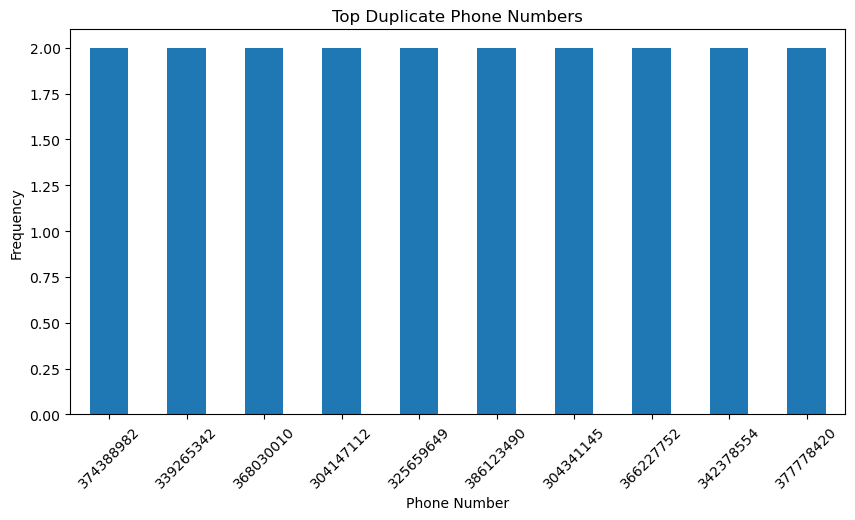

In [17]:
phone_counts = duplicate_phone["Phone_Number"].value_counts()

phone_counts.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top Duplicate Phone Numbers")
plt.xlabel("Phone Number")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

# Step 8: Detect Duplicate CNIC Numbers

## Objective

The CNIC (Computerized National Identity Card) is a unique identifier assigned to every citizen.

Each applicant should submit only one application using a unique CNIC. If the same CNIC appears multiple times, it may indicate duplicate applications or fraudulent behavior.

In this step, we identify all applications that share the same CNIC number.

In [18]:
duplicate_cnic = df[df["CNIC"].duplicated(keep=False)]

print("Total Duplicate CNIC Records:", len(duplicate_cnic))

duplicate_cnic.head()

Total Duplicate CNIC Records: 0


,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,IP_Address,Device_ID,Submission_Date,Submission_Time,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly


In [19]:
df["CNIC"].duplicated().sum()

np.int64(0)

# Step 9: Analyze Duplicate IP Addresses

## Objective

An IP address identifies the network from which an application is submitted.

If multiple internship applications are submitted from the same IP address within a short period, it may indicate suspicious or fraudulent activity.

In this step, we identify duplicate IP addresses to detect potential multiple submissions from the same network.

In [22]:
duplicate_ip = df[df["IP_Address"].duplicated(keep=False)]

print("Total Records with Duplicate IP Addresses:", len(duplicate_ip))

duplicate_ip.head()

Total Records with Duplicate IP Addresses: 49


,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,IP_Address,Device_ID,Submission_Date,Submission_Time,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly
0,APP0001,Allison Hill,allison.hill655@gmail.com,311419610,46048-5108603-3,22,Other,University of the Punjab,BS Computer Science,3.20,...,207.228.165.26,DEV-O36JWBWNUH,6/10/2026,18:00:13,8,Yes,No,No,UI/UX Intern,1
38,APP0039,Elizabeth Fowler,elizabeth.fowler461@gmail.com,394158134,52143-8979730-8,22,Male,GC University Lahore,BS Computer Science,3.58,...,8.189.219.47,DEV-N4U6AVE7E5,6/4/2026,19:26:50,6,Yes,No,No,Frontend Developer Intern,1
40,APP0041,Paula Moreno,paula.moreno158@gmail.com,324034091,91885-3777286-7,20,Female,COMSATS University Islamabad,BS Data Science,3.85,...,166.74.143.24,DEV-VV7PGF7MVQ,5/26/2026,15:56:53,7,No,No,No,UI/UX Intern,1
42,APP0043,Sherry Decker,sherry.decker20@gmail.com,344618086,29597-9854536-6,21,Female,FAST-NUCES,BBA,2.41,...,184.197.62.3,DEV-WIOXD9CSS9,6/23/2026,19:16:03,200,Yes,Yes,Yes,Business Analyst Intern,1
52,APP0053,Crystal Robinson,holly.valentine641@gmail.com,331529665,85047-2843740-3,20,Female,COMSATS University Islamabad,MSc IT,2.46,...,166.74.143.24,DEV-VV7PGF7MVQ,5/26/2026,15:59:00,4,Yes,No,No,UI/UX Intern,1


In [23]:
df["IP_Address"].duplicated().sum()

np.int64(42)

In [24]:
duplicate_ip.sort_values("IP_Address")

,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,IP_Address,Device_ID,Submission_Date,Submission_Time,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly
143,APP0144,Christopher Rubio,christopher.rubio242@gmail.com,385628469,18127-5323142-6,20,Other,UET Lahore,BS Data Science,2.46,...,165.43.24.202,DEV-UPLVQEXUYH,5/14/2026,9:49:07,496,Yes,No,No,Data Science Intern,1
254,APP0255,Cynthia Moore,cynthia.moore694@gmail.com,383288888,72869-9351785-8,21,Female,University of Sargodha,BS Data Science,3.75,...,165.43.24.202,DEV-C4S8PNNE6I,6/22/2026,8:14:23,1051,Yes,Yes,Yes,UI/UX Intern,1
411,APP0412,Lisa Hunter,lisa.hunter876@gmail.com,325569064,77272-1347589-8,20,Female,LUMS,BS Software Engineering,2.28,...,165.43.24.202,DEV-DIX1CNAQ2Y,6/8/2026,8:27:22,743,Yes,Yes,Yes,Business Analyst Intern,1
402,APP0403,Mary Thompson,mary.thompson150@gmail.com,329554163,29058-2140750-7,21,Other,LUMS,BS Data Science,3.27,...,165.43.24.202,DEV-G0NQ4I6R8S,6/9/2026,11:17:16,841,Yes,Yes,Yes,UI/UX Intern,1
222,APP0223,Elizabeth Oliver DDS,elizabeth.oliver.dds526@gmail.com,377778420,86502-3443176-2,27,Female,Bahauddin Zakariya University,BS Artificial Intelligence,2.69,...,165.43.24.202,DEV-HH62MYZ9VL,6/26/2026,3:47:41,759,No,Yes,Yes,Frontend Developer Intern,1
394,APP0395,Tamara Davis,tamara.davis997@gmail.com,301738763,96063-2057136-4,24,Other,GC University Lahore,BS Data Science,3.56,...,165.43.24.202,DEV-I4BNVQRFXN,6/23/2026,11:58:44,733,Yes,Yes,Yes,Frontend Developer Intern,1
98,APP0099,Jessica Smith,jessica.smith677@gmail.com,353347627,13336-9344531-4,24,Female,Punjab University College of IT,MSc IT,3.45,...,166.74.143.24,DEV-VV7PGF7MVQ,5/26/2026,15:56:43,15,No,No,No,UI/UX Intern,1
443,APP0444,Holly Valentine,holly.valentine641@gmail.com,343977034,81758-8946390-7,23,Other,FAST-NUCES,MSc IT,3.42,...,166.74.143.24,DEV-VV7PGF7MVQ,5/26/2026,16:01:19,2,Yes,No,No,Machine Learning Intern,1
40,APP0041,Paula Moreno,paula.moreno158@gmail.com,324034091,91885-3777286-7,20,Female,COMSATS University Islamabad,BS Data Science,3.85,...,166.74.143.24,DEV-VV7PGF7MVQ,5/26/2026,15:56:53,7,No,No,No,UI/UX Intern,1
329,APP0330,Ariana Jennings,ariana.jennings608@gmail.com,303751899,77135-3791472-4,23,Other,University of Sindh,BS Software Engineering,2.42,...,166.74.143.24,DEV-VV7PGF7MVQ,5/26/2026,15:56:32,6,Yes,No,No,Machine Learning Intern,1


In [25]:
ip_counts = duplicate_ip["IP_Address"].value_counts()

ip_counts.head(10)

IP_Address
8.189.219.47      9
166.74.143.24     9
184.197.62.3      8
207.228.165.26    6
165.43.24.202     6
50.161.158.105    6
74.31.120.230     5
Name: count, dtype: int64

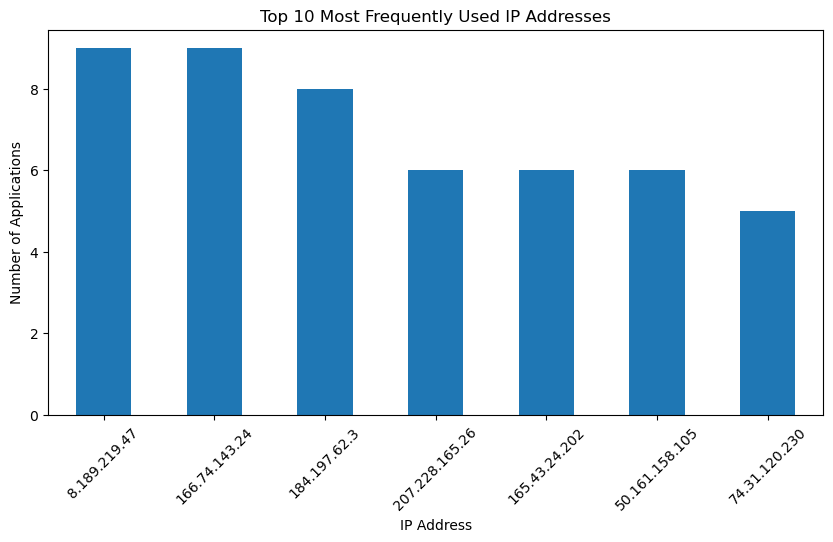

In [26]:
plt.figure(figsize=(10,5))

ip_counts.head(10).plot(kind="bar")

plt.title("Top 10 Most Frequently Used IP Addresses")
plt.xlabel("IP Address")
plt.ylabel("Number of Applications")

plt.xticks(rotation=45)

plt.show()

### Observation

The analysis identified **42 duplicate IP address entries**, representing **49 application records**.

This indicates that multiple applications were submitted from the same network location.

Although sharing an IP address does not always indicate fraudulent behavior (e.g., applicants from the same university or office may use the same network), repeated IP addresses combined with other indicators such as duplicate email addresses or phone numbers can be considered suspicious and should be reviewed further.

In [27]:
fraud_summary = pd.DataFrame({
    "Fraud Indicator": [
        "Duplicate Records",
        "Duplicate Emails",
        "Duplicate Phone Numbers",
        "Duplicate CNIC",
        "Duplicate IP Addresses"
    ],
    "Count": [
        df.duplicated().sum(),
        df["Email"].duplicated().sum(),
        df["Phone_Number"].duplicated().sum(),
        df["CNIC"].duplicated().sum(),
        df["IP_Address"].duplicated().sum()
    ]
})

fraud_summary

,Fraud Indicator,Count
0,Duplicate Records,0
1,Duplicate Emails,18
2,Duplicate Phone Numbers,13
3,Duplicate CNIC,0
4,Duplicate IP Addresses,42


In [28]:
fraud_summary.style.background_gradient(cmap="Reds")

,Fraud Indicator,Count
0,Duplicate Records,0
1,Duplicate Emails,18
2,Duplicate Phone Numbers,13
3,Duplicate CNIC,0
4,Duplicate IP Addresses,42


# Step 10: Analyze Duplicate Device IDs

## Objective

Each application is submitted from a specific device. By analyzing the Device ID, we can identify whether multiple applications have been submitted from the same device.

Although multiple submissions from the same device do not always indicate fraudulent activity, they may become suspicious when combined with duplicate email addresses, phone numbers, or IP addresses.

In this step, we identify repeated Device IDs to detect potential suspicious application behavior.

In [29]:
duplicate_device = df[df["Device_ID"].duplicated(keep=False)]

print("Total Records with Duplicate Device IDs:", len(duplicate_device))

duplicate_device.head()

Total Records with Duplicate Device IDs: 24


,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,IP_Address,Device_ID,Submission_Date,Submission_Time,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly
0,APP0001,Allison Hill,allison.hill655@gmail.com,311419610,46048-5108603-3,22,Other,University of the Punjab,BS Computer Science,3.20,...,207.228.165.26,DEV-O36JWBWNUH,6/10/2026,18:00:13,8,Yes,No,No,UI/UX Intern,1
38,APP0039,Elizabeth Fowler,elizabeth.fowler461@gmail.com,394158134,52143-8979730-8,22,Male,GC University Lahore,BS Computer Science,3.58,...,8.189.219.47,DEV-N4U6AVE7E5,6/4/2026,19:26:50,6,Yes,No,No,Frontend Developer Intern,1
40,APP0041,Paula Moreno,paula.moreno158@gmail.com,324034091,91885-3777286-7,20,Female,COMSATS University Islamabad,BS Data Science,3.85,...,166.74.143.24,DEV-VV7PGF7MVQ,5/26/2026,15:56:53,7,No,No,No,UI/UX Intern,1
52,APP0053,Crystal Robinson,holly.valentine641@gmail.com,331529665,85047-2843740-3,20,Female,COMSATS University Islamabad,MSc IT,2.46,...,166.74.143.24,DEV-VV7PGF7MVQ,5/26/2026,15:59:00,4,Yes,No,No,UI/UX Intern,1
98,APP0099,Jessica Smith,jessica.smith677@gmail.com,353347627,13336-9344531-4,24,Female,Punjab University College of IT,MSc IT,3.45,...,166.74.143.24,DEV-VV7PGF7MVQ,5/26/2026,15:56:43,15,No,No,No,UI/UX Intern,1


In [30]:
df["Device_ID"].duplicated().sum()

np.int64(21)

In [32]:
device_counts = duplicate_device["Device_ID"].value_counts()

device_counts.head(10)

Device_ID
DEV-N4U6AVE7E5    9
DEV-VV7PGF7MVQ    9
DEV-O36JWBWNUH    6
Name: count, dtype: int64

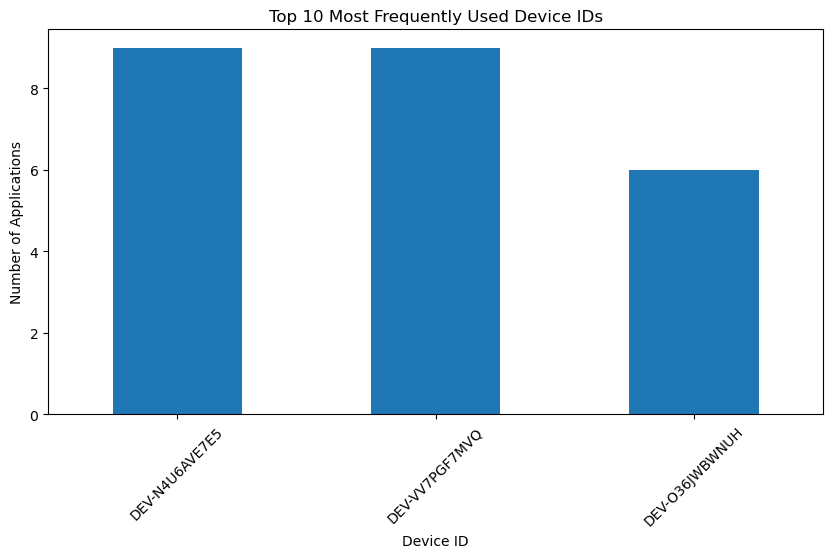

In [33]:
plt.figure(figsize=(10,5))

device_counts.head(10).plot(kind="bar")

plt.title("Top 10 Most Frequently Used Device IDs")
plt.xlabel("Device ID")
plt.ylabel("Number of Applications")

plt.xticks(rotation=45)

plt.show()

### Observation

The analysis identified **21 duplicate Device ID entries**, representing **24 application records**.

This indicates that several internship applications were submitted from the same device.

Although using the same device does not always indicate fraudulent activity, repeated Device IDs combined with duplicate email addresses, phone numbers, or IP addresses may represent suspicious behavior and should be investigated further.

In [34]:
fraud_summary = pd.DataFrame({
    "Fraud Indicator": [
        "Duplicate Records",
        "Duplicate Emails",
        "Duplicate Phone Numbers",
        "Duplicate CNIC",
        "Duplicate IP Addresses",
        "Duplicate Device IDs"
    ],
    "Count": [
        df.duplicated().sum(),
        df["Email"].duplicated().sum(),
        df["Phone_Number"].duplicated().sum(),
        df["CNIC"].duplicated().sum(),
        df["IP_Address"].duplicated().sum(),
        df["Device_ID"].duplicated().sum()
    ]
})

fraud_summary

,Fraud Indicator,Count
0,Duplicate Records,0
1,Duplicate Emails,18
2,Duplicate Phone Numbers,13
3,Duplicate CNIC,0
4,Duplicate IP Addresses,42
5,Duplicate Device IDs,21


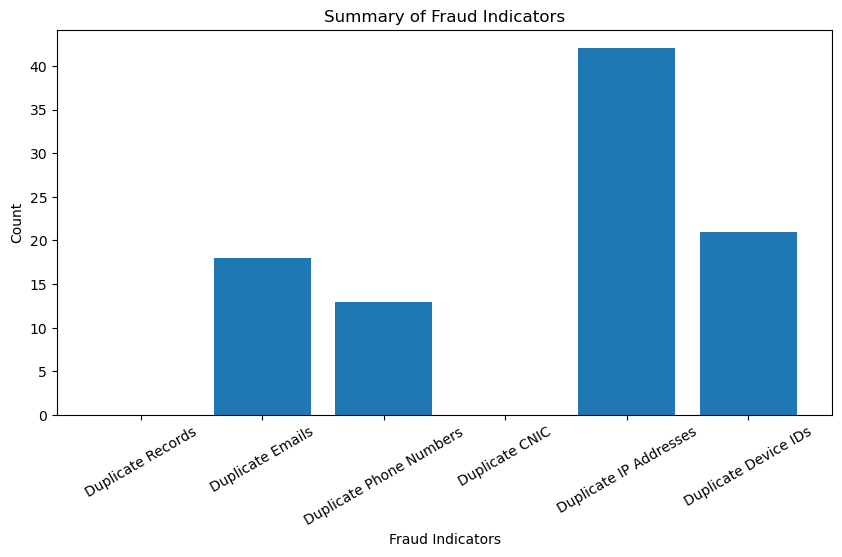

In [35]:
plt.figure(figsize=(10,5))

plt.bar(fraud_summary["Fraud Indicator"], fraud_summary["Count"])

plt.title("Summary of Fraud Indicators")
plt.xlabel("Fraud Indicators")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

In [36]:
df[["Submission_Date", "Submission_Time"]].head()

,Submission_Date,Submission_Time
0,6/10/2026,18:00:13
1,5/24/2026,18:27:02
2,5/11/2026,15:30:03
3,6/21/2026,11:48:49
4,6/2/2026,19:47:47


# Step 11: Rapid Submission Analysis

## Objective

One common indicator of fraudulent activity is the submission of multiple applications within a very short period of time.

Fraudsters often use automated scripts or repeatedly submit applications in quick succession.

In this step, we combine the submission date and time into a single timestamp, calculate the time difference between consecutive applications, and identify submissions made within 30 seconds.

These applications will be considered potentially suspicious and reviewed further.

In [37]:
# Combine Submission_Date and Submission_Time into one datetime column

df["Submission_DateTime"] = pd.to_datetime(
    df["Submission_Date"] + " " + df["Submission_Time"]
)

# Display first five records

df[["Submission_Date", "Submission_Time", "Submission_DateTime"]].head()

,Submission_Date,Submission_Time,Submission_DateTime
0,6/10/2026,18:00:13,2026-06-10 18:00:13
1,5/24/2026,18:27:02,2026-05-24 18:27:02
2,5/11/2026,15:30:03,2026-05-11 15:30:03
3,6/21/2026,11:48:49,2026-06-21 11:48:49
4,6/2/2026,19:47:47,2026-06-02 19:47:47


In [38]:
# Sort dataset according to submission time
df = df.sort_values("Submission_DateTime")
df.head()

,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,Device_ID,Submission_Date,Submission_Time,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly,Submission_DateTime
102,APP0103,Rebecca Valencia,rebecca.valencia486@gmail.com,324447632,99881-1156104-4,26,Other,University of the Punjab,BBA,3.26,...,DEV-JSHZKBRH7L,5/1/2026,6:22:48,193,Yes,No,No,Software QA Intern,0,2026-05-01 06:22:48
57,APP0058,Richard Aguirre,judy.baker508@gmail.com,379861274,57419-2310346-9,21,Male,Islamia University Bahawalpur,BS Data Science,3.17,...,DEV-S3QSQCQ30O,5/1/2026,7:01:35,943,Yes,Yes,Yes,Machine Learning Intern,1,2026-05-01 07:01:35
242,APP0243,Kevin Walters,kevin.walters380@gmail.com,356288577,41404-7060108-6,26,Other,University of Sargodha,BS Artificial Intelligence,3.68,...,DEV-ET81IQY5SX,5/1/2026,7:17:28,1189,Yes,No,Yes,Business Analyst Intern,0,2026-05-01 07:17:28
367,APP0368,Holly Farmer,holly.farmer391@gmail.com,373323803,54996-4070056-1,24,Female,LUMS,MSc IT,3.69,...,DEV-1SAV9CNG8T,5/1/2026,10:51:39,514,Yes,Yes,No,Business Analyst Intern,0,2026-05-01 10:51:39
199,APP0200,Nathan Freeman,nathan.freeman577@gmail.com,394563416,86486-1069218-8,22,Female,Government College University Faisalabad,BS Computer Science,2.62,...,DEV-V84FC3XQ8V,5/1/2026,13:31:38,517,No,Yes,No,Business Analyst Intern,0,2026-05-01 13:31:38


In [39]:
# Calculate the time difference between consecutive applications

df["Time_Difference"] = df["Submission_DateTime"].diff()

df[["Submission_DateTime", "Time_Difference"]].head()

,Submission_DateTime,Time_Difference
102,2026-05-01 06:22:48,NaT
57,2026-05-01 07:01:35,0 days 00:38:47
242,2026-05-01 07:17:28,0 days 00:15:53
367,2026-05-01 10:51:39,0 days 03:34:11
199,2026-05-01 13:31:38,0 days 02:39:59


In [40]:
# Find applications submitted within 30 seconds

rapid_submissions = df[df["Time_Difference"] < pd.Timedelta(seconds=30)]

print("Total Rapid Submissions:", len(rapid_submissions))

rapid_submissions.head()

Total Rapid Submissions: 14


,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,Submission_Date,Submission_Time,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly,Submission_DateTime,Time_Difference
256,APP0257,Susan Murray MD,susan.murray.md374@gmail.com,364056507,80310-5521152-1,27,Other,Islamia University Bahawalpur,BS Statistics,2.48,...,5/13/2026,8:56:33,512,Yes,Yes,Yes,Data Science Intern,0,2026-05-13 08:56:33,0 days 00:00:26
98,APP0099,Jessica Smith,jessica.smith677@gmail.com,353347627,13336-9344531-4,24,Female,Punjab University College of IT,MSc IT,3.45,...,5/26/2026,15:56:43,15,No,No,No,UI/UX Intern,1,2026-05-26 15:56:43,0 days 00:00:11
40,APP0041,Paula Moreno,paula.moreno158@gmail.com,324034091,91885-3777286-7,20,Female,COMSATS University Islamabad,BS Data Science,3.85,...,5/26/2026,15:56:53,7,No,No,No,UI/UX Intern,1,2026-05-26 15:56:53,0 days 00:00:10
436,APP0437,Ralph Anderson,ralph.anderson811@gmail.com,395046832,15789-8986163-4,22,Other,University of Sindh,BS Information Technology,3.77,...,5/26/2026,15:57:18,7,No,No,No,Backend Developer Intern,1,2026-05-26 15:57:18,0 days 00:00:25
465,APP0466,Jeffrey Mendez,jeffrey.mendez169@gmail.com,304341145,78359-6597133-9,23,Female,University of Sindh,BS Information Technology,2.35,...,5/26/2026,15:57:44,12,No,No,No,Frontend Developer Intern,1,2026-05-26 15:57:44,0 days 00:00:26


In [41]:
rapid_submissions[
    [
        "Applicant_Name",
        "Email",
        "Submission_DateTime",
        "Time_Difference"
    ]
]

,Applicant_Name,Email,Submission_DateTime,Time_Difference
256,Susan Murray MD,susan.murray.md374@gmail.com,2026-05-13 08:56:33,0 days 00:00:26
98,Jessica Smith,jessica.smith677@gmail.com,2026-05-26 15:56:43,0 days 00:00:11
40,Paula Moreno,paula.moreno158@gmail.com,2026-05-26 15:56:53,0 days 00:00:10
436,Ralph Anderson,ralph.anderson811@gmail.com,2026-05-26 15:57:18,0 days 00:00:25
465,Jeffrey Mendez,jeffrey.mendez169@gmail.com,2026-05-26 15:57:44,0 days 00:00:26
371,Debra White,debra.white5@gmail.com,2026-05-26 15:59:20,0 days 00:00:20
356,Jesse Perry,jesse.perry766@gmail.com,2026-06-04 19:23:12,0 days 00:00:20
368,Renee Bruce,renee.bruce880@gmail.com,2026-06-04 19:23:21,0 days 00:00:09
262,Timothy Romero,timothy.romero333@gmail.com,2026-06-04 19:23:28,0 days 00:00:07
346,Sharon Boyd,sharon.boyd315@gmail.com,2026-06-04 19:24:55,0 days 00:00:19


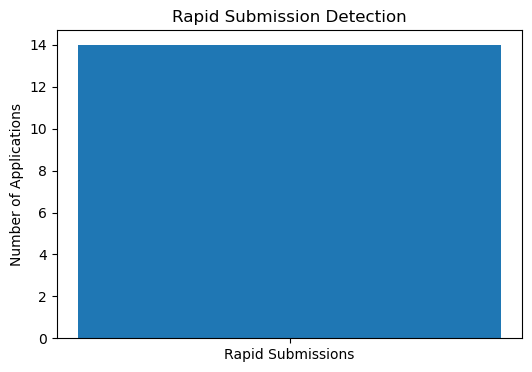

In [42]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Rapid Submissions"],
    [len(rapid_submissions)]
)

plt.title("Rapid Submission Detection")
plt.ylabel("Number of Applications")

plt.show()

### Observation

The analysis detected **14 rapid submissions**, where applications were submitted within **30 seconds** of the previous application.

Such rapid submissions may indicate automated form submissions, repeated attempts by the same applicant, or suspicious application behavior.

Although rapid submissions alone do not confirm fraudulent activity, they become a strong fraud indicator when combined with duplicate email addresses, phone numbers, IP addresses, or Device IDs.

These records will be further analyzed using machine learning algorithms in the next phase of this project.

# Step 12: Feature Selection

## Objective

Machine learning models cannot use every column in a dataset. Some columns contain unique identifiers or personal information that do not contribute to identifying fraudulent behavior.

In this step, we carefully select the most relevant features that describe applicant behavior and application characteristics.

Selecting appropriate features improves model performance and helps the algorithm detect anomalies more accurately.

In [43]:
features = [

    "Age",
    "Gender",
    "University",
    "Degree",
    "CGPA",
    "Experience_Years",
    "Skills",
    "City",
    "IP_Address",
    "Device_ID",
    "Submission_Duration",
    "Resume_Uploaded",
    "Email_Verified",
    "Phone_Verified",
    "Internship_Position"

]

X = df[features]

X.head()

,Age,Gender,University,Degree,CGPA,Experience_Years,Skills,City,IP_Address,Device_ID,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position
102,26,Other,University of the Punjab,BBA,3.26,2.1,"Power BI, C++, Git, HTML/CSS, Node.js",Karachi,128.101.102.200,DEV-JSHZKBRH7L,193,Yes,No,No,Software QA Intern
57,21,Male,Islamia University Bahawalpur,BS Data Science,3.17,0.4,"C++, Statistics, Power BI, Deep Learning",Hyderabad,150.250.46.231,DEV-S3QSQCQ30O,943,Yes,Yes,Yes,Machine Learning Intern
242,26,Other,University of Sargodha,BS Artificial Intelligence,3.68,2.4,"Statistics, Scikit-learn",Hyderabad,214.71.13.155,DEV-ET81IQY5SX,1189,Yes,No,Yes,Business Analyst Intern
367,24,Female,LUMS,MSc IT,3.69,1.5,"React, Scikit-learn, Deep Learning",Faisalabad,90.41.173.116,DEV-1SAV9CNG8T,514,Yes,Yes,No,Business Analyst Intern
199,22,Female,Government College University Faisalabad,BS Computer Science,2.62,1.5,"Pandas, Python",Multan,175.62.201.96,DEV-V84FC3XQ8V,517,No,Yes,No,Business Analyst Intern


In [44]:
X.shape

(500, 15)

# Step 13: Label Encoding

## Objective

Machine learning algorithms cannot process categorical (text) data directly. Therefore, categorical features must be converted into numerical values before training the model.

In this step, Label Encoding is applied to transform text-based categories into numeric labels while preserving the information required for anomaly detection.

This preprocessing step ensures that all selected features are in a format suitable for machine learning algorithms.

In [45]:
from sklearn.preprocessing import LabelEncoder

In [46]:
# List of categorical columns

categorical_columns = [

    "Gender",
    "University",
    "Degree",
    "Skills",
    "City",
    "IP_Address",
    "Device_ID",
    "Resume_Uploaded",
    "Email_Verified",
    "Phone_Verified",
    "Internship_Position"

]

In [48]:
X = df[features].copy()

In [49]:
# Create LabelEncoder object

label_encoder = LabelEncoder()

# Apply Label Encoding

for column in categorical_columns:
    X[column] = label_encoder.fit_transform(X[column])

X.head()

,Age,Gender,University,Degree,CGPA,Experience_Years,Skills,City,IP_Address,Device_ID,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position
102,26,2,13,0,3.26,2.1,306,5,67,248,193,1,0,0,6
57,21,1,5,3,3.17,0.4,18,3,119,360,943,1,1,1,5
242,26,2,11,1,3.68,2.4,459,3,271,178,1189,1,0,1,1
367,24,0,6,7,3.69,1.5,376,1,433,30,514,1,1,0,1
199,22,0,4,2,2.62,1.5,298,7,174,405,517,0,1,0,1


In [50]:
X.dtypes

Age                      int64
Gender                   int64
University               int64
Degree                   int64
CGPA                   float64
Experience_Years       float64
Skills                   int64
City                     int64
IP_Address               int64
Device_ID                int64
Submission_Duration      int64
Resume_Uploaded          int64
Email_Verified           int64
Phone_Verified           int64
Internship_Position      int64
dtype: object

# Step 14: Feature Scaling

## Objective

Machine learning algorithms perform better when all numerical features are on a similar scale.

In our dataset, some features such as **Submission_Duration** have values in the hundreds, while others such as **CGPA** have values between 2 and 4.

If the features are not scaled, variables with larger values may dominate the model and reduce its performance.

To avoid this issue, we use **StandardScaler**, which standardizes each feature by transforming it to have:

- Mean = 0
- Standard Deviation = 1

This preprocessing step improves the performance and stability of machine learning algorithms such as Isolation Forest and K-Means Clustering.

In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
# Create StandardScaler object

scaler = StandardScaler()

In [53]:
# Scale all selected features

X_scaled = scaler.fit_transform(X)

In [54]:
# Convert scaled data back to DataFrame

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Age,Gender,University,Degree,CGPA,Experience_Years,Skills,City,IP_Address,Device_ID,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position
0,0.336197,1.161224,1.470460,-1.640336,0.391300,0.177082,0.448198,-0.113839,-1.261291,0.033582,-1.412983,0.355142,-2.012587,-1.975338,1.044568
1,-0.492691,-0.068886,-0.414141,-0.295063,0.243056,-0.562936,-1.597656,-0.691701,-0.863417,0.848389,0.926630,0.355142,0.496873,0.506242,0.606043
2,0.336197,1.161224,0.999310,-1.191912,1.083109,0.307673,1.535059,-0.691701,0.299599,-0.475673,1.694024,0.355142,-2.012587,0.506242,-1.148061
3,0.004642,-1.298996,-0.178566,1.498634,1.099581,-0.084101,0.945455,-1.269562,1.539130,-1.552382,-0.411628,0.355142,0.496873,-1.975338,-1.148061
4,-0.326913,-1.298996,-0.649716,-0.743488,-0.662885,-0.084101,0.391369,0.464023,-0.442589,1.175767,-0.402270,-2.815772,0.496873,-1.975338,-1.148061


In [55]:
# Check the mean of scaled features

X_scaled.mean().round(2)

Age                   -0.0
Gender                -0.0
University            -0.0
Degree                 0.0
CGPA                  -0.0
Experience_Years      -0.0
Skills                -0.0
City                  -0.0
IP_Address             0.0
Device_ID              0.0
Submission_Duration    0.0
Resume_Uploaded       -0.0
Email_Verified        -0.0
Phone_Verified        -0.0
Internship_Position    0.0
dtype: float64

In [56]:
# Check the standard deviation

X_scaled.std().round(2)

Age                    1.0
Gender                 1.0
University             1.0
Degree                 1.0
CGPA                   1.0
Experience_Years       1.0
Skills                 1.0
City                   1.0
IP_Address             1.0
Device_ID              1.0
Submission_Duration    1.0
Resume_Uploaded        1.0
Email_Verified         1.0
Phone_Verified         1.0
Internship_Position    1.0
dtype: float64

### Observation

All selected features were successfully standardized using StandardScaler.

The transformed dataset now has features with approximately zero mean and unit variance, ensuring that no single feature dominates the machine learning models due to differences in scale.

The scaled dataset is now ready for anomaly detection using Isolation Forest and clustering using K-Means.

In [57]:
X_scaled.shape

(500, 15)

# Step 15: Fraud Detection using Isolation Forest

## Objective

The primary objective of this step is to identify suspicious internship applications using the Isolation Forest algorithm.

The algorithm returns:

- **1** → Normal Application
- **-1** → Anomalous (Suspicious) Application

These predictions will be further analyzed and compared with the injected anomaly labels provided in the dataset.

In [58]:
from sklearn.ensemble import IsolationForest

In [59]:
# Create Isolation Forest model

isolation_forest = IsolationForest(
    contamination=0.10,
    random_state=42
)

In [60]:
# Train the Isolation Forest model

isolation_forest.fit(X_scaled)

,n_estimators,100
,max_samples,'auto'
,contamination,0.1
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [61]:
# Predict anomalies

predictions = isolation_forest.predict(X_scaled)

predictions[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [63]:
pd.Series(predictions).value_counts()

 1    450
-1     50
Name: count, dtype: int64

In [65]:
df.columns

Index(['Application_ID', 'Applicant_Name', 'Email', 'Phone_Number', 'CNIC',
       'Age', 'Gender', 'University', 'Degree', 'CGPA', 'Experience_Years',
       'Skills', 'City', 'IP_Address', 'Device_ID', 'Submission_Date',
       'Submission_Time', 'Submission_Duration', 'Resume_Uploaded',
       'Email_Verified', 'Phone_Verified', 'Internship_Position',
       'Is_Injected_Anomaly', 'Submission_DateTime', 'Time_Difference'],
      dtype='object')

In [66]:
predictions[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [67]:
df["IF_Prediction"] = predictions

In [68]:
df.columns

Index(['Application_ID', 'Applicant_Name', 'Email', 'Phone_Number', 'CNIC',
       'Age', 'Gender', 'University', 'Degree', 'CGPA', 'Experience_Years',
       'Skills', 'City', 'IP_Address', 'Device_ID', 'Submission_Date',
       'Submission_Time', 'Submission_Duration', 'Resume_Uploaded',
       'Email_Verified', 'Phone_Verified', 'Internship_Position',
       'Is_Injected_Anomaly', 'Submission_DateTime', 'Time_Difference',
       'IF_Prediction'],
      dtype='object')

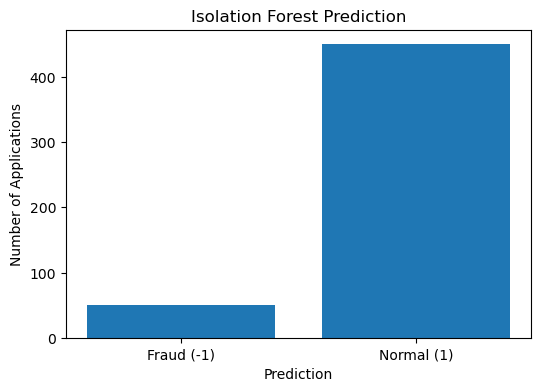

In [69]:
plt.figure(figsize=(6,4))

counts = df["IF_Prediction"].value_counts().sort_index()

plt.bar(["Fraud (-1)", "Normal (1)"], counts.values)

plt.title("Isolation Forest Prediction")
plt.xlabel("Prediction")
plt.ylabel("Number of Applications")

plt.show()

# Step 16: Analyze Suspicious Applications

## Objective

After detecting anomalies using the Isolation Forest model, the next step is to analyze the suspicious applications.


In [70]:
# Extract suspicious applications

fraud_cases = df[df["IF_Prediction"] == -1]

fraud_cases.head()

,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,Submission_Time,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly,Submission_DateTime,Time_Difference,IF_Prediction
370,APP0371,Allison Hickman,allison.hickman541@gmail.com,304155440,21689-6152615-9,22,Other,COMSATS University Islamabad,BS Information Technology,3.11,...,12:20:01,226,No,Yes,Yes,UI/UX Intern,0,2026-05-02 12:20:01,0 days 03:26:37,-1
129,APP0130,Megan Orr,megan.orr129@gmail.com,335221936,20494-4532803-2,26,Male,University of the Punjab,BS Computer Science,3.79,...,9:55:01,859,Yes,No,No,Software QA Intern,0,2026-05-04 09:55:01,0 days 03:02:29,-1
101,APP0102,Cameron Parker,cameron.parker467@gmail.com,389793234,54280-8275695-2,62,Female,COMSATS University Islamabad,BS Data Science,2.48,...,16:23:44,886,Yes,Yes,Yes,UI/UX Intern,1,2026-05-05 16:23:44,0 days 04:22:22,-1
229,APP0230,Lori Guerrero,lori.guerrero193@gmail.com,372822649,53101-8575505-4,21,Male,University of the Punjab,BS Software Engineering,2.25,...,16:13:45,578,No,No,Yes,Backend Developer Intern,0,2026-05-07 16:13:45,0 days 01:24:03,-1
112,APP0113,Julia Torres,julia.torres396@gmail.com,345745083,13238-9671603-5,27,Female,University of Sargodha,BBA,3.73,...,0:03:10,944,Yes,Yes,Yes,Data Analytics Intern,1,2026-05-08 00:03:10,0 days 06:54:06,-1


In [71]:
print("Total Suspicious Applications:", len(fraud_cases))

Total Suspicious Applications: 50


In [72]:
fraud_cases[[
    "Application_ID",
    "Applicant_Name",
    "Email",
    "Phone_Number",
    "IP_Address",
    "Device_ID",
    "Submission_Duration",
    "Internship_Position"
]].head(10)

,Application_ID,Applicant_Name,Email,Phone_Number,IP_Address,Device_ID,Submission_Duration,Internship_Position
370,APP0371,Allison Hickman,allison.hickman541@gmail.com,304155440,112.91.189.175,DEV-Z6D86ZCHHX,226,UI/UX Intern
129,APP0130,Megan Orr,megan.orr129@gmail.com,335221936,196.42.53.68,DEV-WD7OI0PESG,859,Software QA Intern
101,APP0102,Cameron Parker,cameron.parker467@gmail.com,389793234,6.86.63.94,DEV-Z2NX1WVBD4,886,UI/UX Intern
229,APP0230,Lori Guerrero,lori.guerrero193@gmail.com,372822649,53.119.149.169,DEV-SQNAL6O9EP,578,Backend Developer Intern
112,APP0113,Julia Torres,julia.torres396@gmail.com,345745083,137.3.33.54,DEV-Y15PDTZ91X,944,Data Analytics Intern
427,APP0428,Emily Bennett,emily.bennett609@gmail.com,382954443,10.54.28.241,DEV-K8EJNFMOCT,690,UI/UX Intern
462,APP0463,Riley Bryant,riley.bryant518@gmail.com,373582270,161.121.188.14,DEV-Z5X51O0LQB,351,Business Analyst Intern
218,APP0219,Justin Torres,justin.torres761@gmail.com,305716653,51.202.56.223,DEV-JSGG0YVGV0,445,UI/UX Intern
201,APP0202,Ricky Davis II,ricky.davis.ii525@gmail.com,339214511,11.174.237.174,DEV-IYFRWSKP6R,1187,Data Science Intern
82,APP0083,Michael Evans,michael.evans123@gmail.com,381883692,95.102.149.145,DEV-20IN8910T2,186,Data Analytics Intern


In [73]:
fraud_cases.to_csv("Suspicious_Applications.csv", index=False)

### Observation

The Isolation Forest model identified **50 suspicious internship applications**.

These records were extracted separately for detailed investigation.

The suspicious applications may contain repeated IP addresses, shared Device IDs, duplicate contact information, or unusually fast submission behavior.

Saving these records as a separate CSV file makes it easier for recruiters or administrators to review and verify suspicious applications manually.

# Step 17: Fraud Pattern Analysis

## Objective

After identifying suspicious internship applications using the Isolation Forest algorithm, the next step is to analyze the characteristics of these applications.

In [74]:
# Duplicate IP Addresses among suspicious applications

duplicate_ip = fraud_cases["IP_Address"].duplicated().sum()

print("Duplicate IP Addresses:", duplicate_ip)

Duplicate IP Addresses: 15


In [75]:
# Duplicate Device IDs among suspicious applications

duplicate_device = fraud_cases["Device_ID"].duplicated().sum()

print("Duplicate Device IDs:", duplicate_device)

Duplicate Device IDs: 15


In [76]:
# Duplicate Emails among suspicious applications

duplicate_email = fraud_cases["Email"].duplicated().sum()

print("Duplicate Emails:", duplicate_email)

Duplicate Emails: 1


In [77]:
# Average Submission Duration

fraud_cases["Submission_Duration"].describe()

count      50.000000
mean      498.720000
std       441.222191
min         2.000000
25%         9.000000
50%       517.000000
75%       883.250000
max      1192.000000
Name: Submission_Duration, dtype: float64

In [78]:
# Most targeted internship positions

fraud_cases["Internship_Position"].value_counts()

Internship_Position
UI/UX Intern                 17
Backend Developer Intern      7
Machine Learning Intern       6
Software QA Intern            5
Frontend Developer Intern     5
Data Science Intern           4
Data Analytics Intern         3
Business Analyst Intern       3
Name: count, dtype: int64

In [79]:
# City-wise suspicious applications

fraud_cases["City"].value_counts().head(10)

City
Sialkot       8
Bahawalpur    6
Sargodha      6
Lahore        5
Faisalabad    5
Peshawar      5
Hyderabad     4
Karachi       4
Multan        3
Gujranwala    3
Name: count, dtype: int64

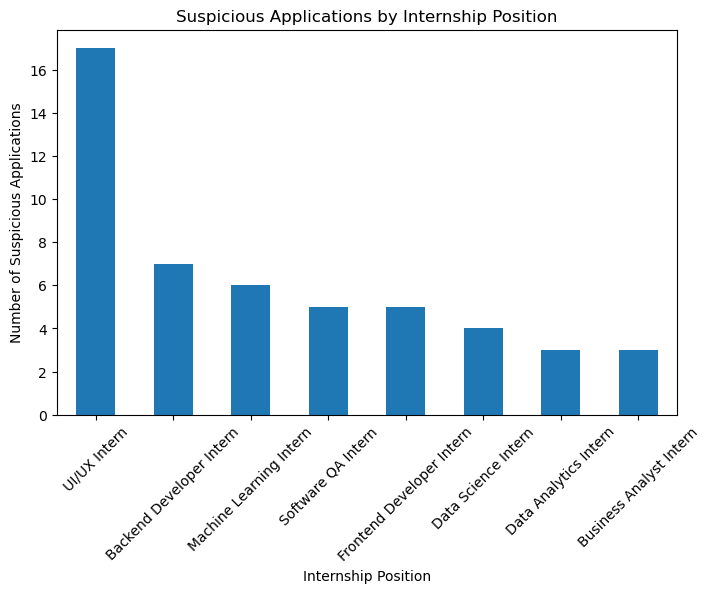

In [80]:
plt.figure(figsize=(8,5))

fraud_cases["Internship_Position"].value_counts().plot(kind="bar")

plt.title("Suspicious Applications by Internship Position")
plt.xlabel("Internship Position")
plt.ylabel("Number of Suspicious Applications")

plt.xticks(rotation=45)

plt.show()

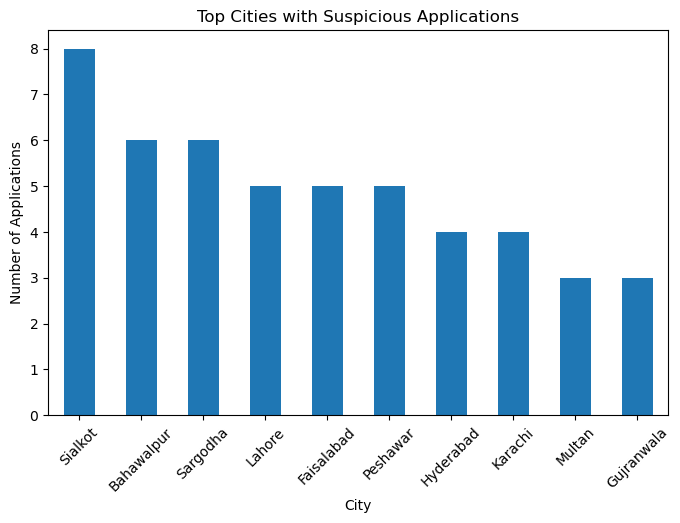

In [81]:
plt.figure(figsize=(8,5))

fraud_cases["City"].value_counts().head(10).plot(kind="bar")

plt.title("Top Cities with Suspicious Applications")
plt.xlabel("City")
plt.ylabel("Number of Applications")

plt.xticks(rotation=45)

plt.show()

### Observation

The fraud pattern analysis revealed several common characteristics among suspicious internship applications.

The most notable indicators included repeated IP addresses, shared Device IDs, duplicate email addresses, and unusually short submission durations.

These findings suggest that some applications may have been submitted from the same device or network, indicating possible fraudulent or automated application behavior.

The organization can use these insights to implement stronger verification mechanisms, such as IP monitoring, device fingerprinting, email verification, and submission rate limits.

# Step 18: K-Means Clustering

## Objective

In addition to Isolation Forest, K-Means Clustering is used to group internship applications based on similarities in their features.

Unlike Isolation Forest, K-Means does not directly classify records as fraudulent or normal. Instead, it groups similar applications into clusters.

By analyzing these clusters, we can identify groups that exhibit unusual characteristics and may represent suspicious internship applications.

Using multiple machine learning techniques improves the reliability of fraud detection and provides deeper insights into applicant behavior.

In [82]:
from sklearn.cluster import KMeans

# Step 19: Elbow Method

## Objective

Before applying K-Means Clustering, it is important to determine the optimal number of clusters.

In [83]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

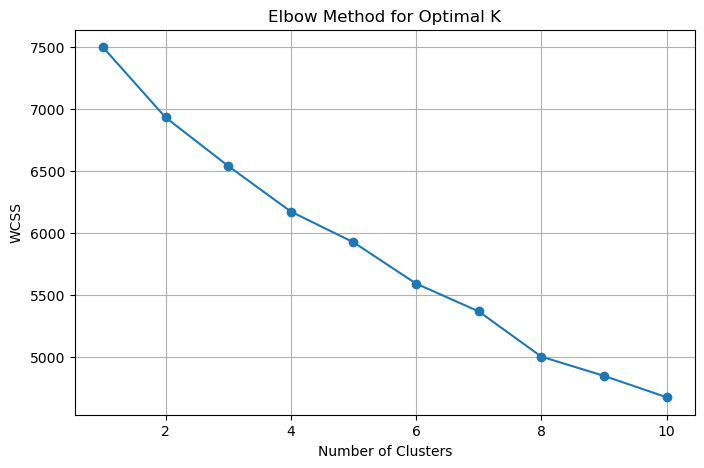

In [84]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method for Optimal K")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

# Step 20: Train the K-Means Model

## Objective

After selecting the optimal number of clusters using the Elbow Method, the K-Means algorithm is trained to group internship applications into clusters.

Each application is assigned to one cluster based on its similarity to other applications.

In [85]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [86]:
df["Cluster"] = clusters

df.head()

,Application_ID,Applicant_Name,Email,Phone_Number,CNIC,Age,Gender,University,Degree,CGPA,...,Submission_Duration,Resume_Uploaded,Email_Verified,Phone_Verified,Internship_Position,Is_Injected_Anomaly,Submission_DateTime,Time_Difference,IF_Prediction,Cluster
102,APP0103,Rebecca Valencia,rebecca.valencia486@gmail.com,324447632,99881-1156104-4,26,Other,University of the Punjab,BBA,3.26,...,193,Yes,No,No,Software QA Intern,0,2026-05-01 06:22:48,NaT,1,0
57,APP0058,Richard Aguirre,judy.baker508@gmail.com,379861274,57419-2310346-9,21,Male,Islamia University Bahawalpur,BS Data Science,3.17,...,943,Yes,Yes,Yes,Machine Learning Intern,1,2026-05-01 07:01:35,0 days 00:38:47,1,1
242,APP0243,Kevin Walters,kevin.walters380@gmail.com,356288577,41404-7060108-6,26,Other,University of Sargodha,BS Artificial Intelligence,3.68,...,1189,Yes,No,Yes,Business Analyst Intern,0,2026-05-01 07:17:28,0 days 00:15:53,1,0
367,APP0368,Holly Farmer,holly.farmer391@gmail.com,373323803,54996-4070056-1,24,Female,LUMS,MSc IT,3.69,...,514,Yes,Yes,No,Business Analyst Intern,0,2026-05-01 10:51:39,0 days 03:34:11,1,0
199,APP0200,Nathan Freeman,nathan.freeman577@gmail.com,394563416,86486-1069218-8,22,Female,Government College University Faisalabad,BS Computer Science,2.62,...,517,No,Yes,No,Business Analyst Intern,0,2026-05-01 13:31:38,0 days 02:39:59,1,2


In [87]:
df["Cluster"].value_counts()

Cluster
0    240
1    204
2     56
Name: count, dtype: int64

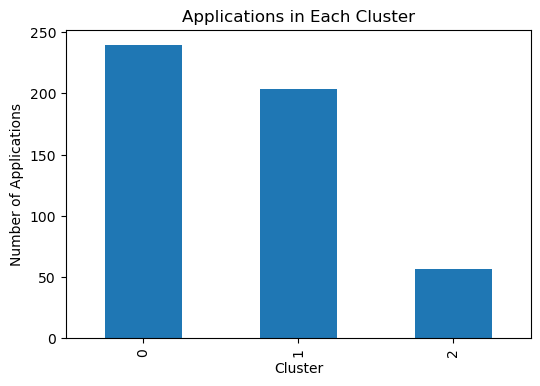

In [88]:
plt.figure(figsize=(6,4))

df["Cluster"].value_counts().sort_index().plot(kind="bar")

plt.title("Applications in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Applications")

plt.show()

In [89]:
# Cluster Distribution

cluster_summary = df["Cluster"].value_counts().sort_index()

print(cluster_summary)

Cluster
0    240
1    204
2     56
Name: count, dtype: int64


### Observation

The K-Means algorithm grouped the internship applications into three clusters based on similarities in applicant characteristics.

Each cluster represents a different group of applications with similar patterns.

Further analysis can be performed to identify whether any cluster contains a higher concentration of suspicious applications detected by the Isolation Forest model.

# Step 21: Cluster Profiling

## Objective

After creating clusters, we analyze the characteristics of each cluster.

In [90]:
cluster_profile = df.groupby("Cluster")[[
    "Age",
    "CGPA",
    "Experience_Years",
    "Submission_Duration"
]].mean().round(2)

cluster_profile

,Age,CGPA,Experience_Years,Submission_Duration
Cluster,,,,
0,23.95,3.09,1.44,716.83
1,23.91,2.91,1.97,607.24
2,24.30,3.13,1.79,483.23


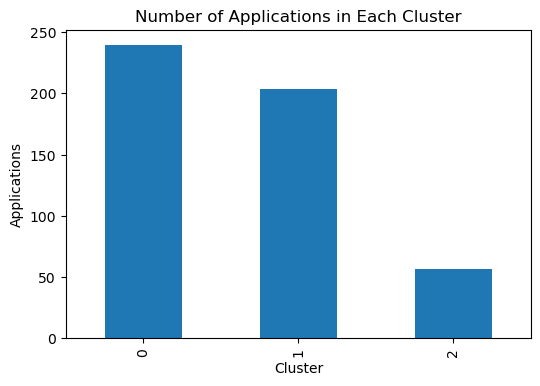

In [91]:
plt.figure(figsize=(6,4))

df["Cluster"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Applications in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Applications")

plt.show()

# Step 23: Comparing K-Means Clusters with Isolation Forest

## Objective

Both Isolation Forest and K-Means were applied to analyze internship applications.

In [92]:
comparison = pd.crosstab(
    df["Cluster"],
    df["IF_Prediction"]
)

comparison

IF_Prediction,-1,1
Cluster,,
0,10,230
1,12,192
2,28,28


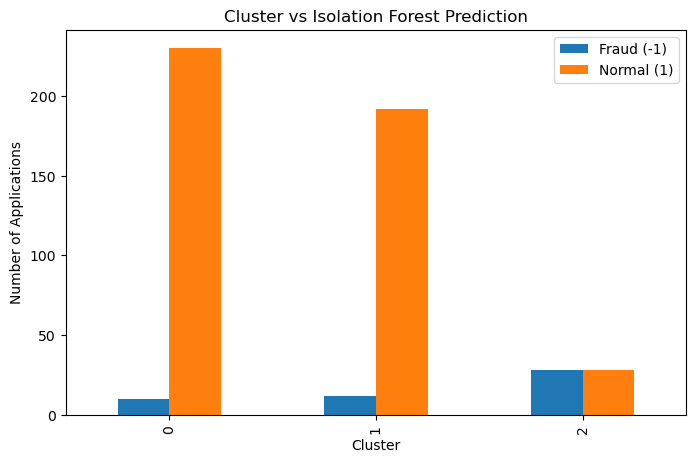

In [93]:
comparison.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Cluster vs Isolation Forest Prediction")

plt.xlabel("Cluster")

plt.ylabel("Number of Applications")

plt.legend(["Fraud (-1)", "Normal (1)"])

plt.show()

### Observation

The comparison between K-Means Clustering and Isolation Forest revealed that Cluster 2 contains the highest concentration of suspicious internship applications.

While Clusters 0 and 1 are dominated by normal applications, Cluster 2 consists of an equal number of normal and suspicious records, indicating that applicants in this cluster exhibit more unusual behavioral patterns.

This result demonstrates that combining K-Means Clustering with Isolation Forest provides deeper insights into the structure of the dataset and helps identify groups with a higher likelihood of fraudulent activity.

# Step 24: Model Evaluation

## Objective

After detecting suspicious internship applications using Isolation Forest, the model's predictions are evaluated against the actual anomaly labels available in the dataset.

This evaluation measures how effectively the model identified fraudulent applications using performance metrics such as:

- Confusion Matrix
- Precision
- Recall
- F1-Score
- Accuracy

These metrics provide a comprehensive assessment of the anomaly detection model.

In [94]:
# Convert Isolation Forest predictions into binary labels

df["Fraud_Prediction"] = df["IF_Prediction"].map({
    1: 0,
    -1: 1
})

In [95]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df["Is_Injected_Anomaly"],
    df["Fraud_Prediction"]
)

cm

array([[380,  19],
       [ 70,  31]])

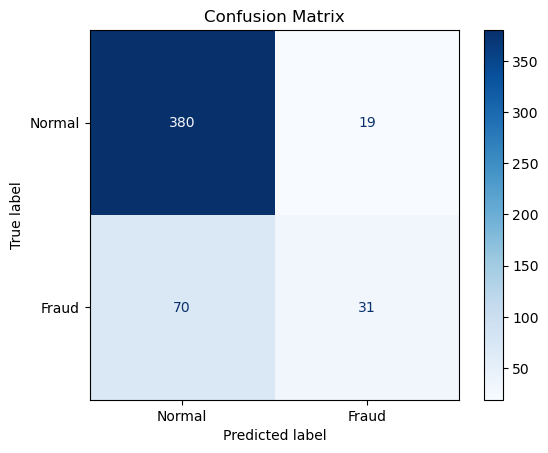

In [96]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [97]:
from sklearn.metrics import classification_report

print(classification_report(
    df["Is_Injected_Anomaly"],
    df["Fraud_Prediction"]
))

              precision    recall  f1-score   support

           0       0.84      0.95      0.90       399
           1       0.62      0.31      0.41       101

    accuracy                           0.82       500
   macro avg       0.73      0.63      0.65       500
weighted avg       0.80      0.82      0.80       500



In [98]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    df["Is_Injected_Anomaly"],
    df["Fraud_Prediction"]
)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 82.20%


### Observation

The Isolation Forest model achieved an overall accuracy of **82.2%** in detecting fraudulent internship applications.

The model performed very well in identifying normal applications, achieving a precision of 84% and a recall of 95%.

For fraudulent applications, the model achieved a precision of 62% and a recall of 31%, indicating that while many detected anomalies were genuine, some fraudulent applications remained undetected.

Overall, the model demonstrated good performance for unsupervised anomaly detection and provides a strong baseline for identifying suspicious internship applications.

## Business Insights

• The dataset contained 500 internship applications.

• Isolation Forest identified 50 suspicious applications.

• Several duplicate email addresses, phone numbers, IP addresses, and Device IDs were detected, indicating possible duplicate or fake submissions.

• Rapid submission behavior was observed in multiple applications, suggesting possible automated form submissions.

• K-Means Clustering grouped applicants into three clusters, with Cluster 2 containing the highest concentration of suspicious applications.

• The Isolation Forest model achieved an overall accuracy of 82.2%, demonstrating effective anomaly detection for internship applications.

• Combining Isolation Forest with K-Means Clustering provided deeper insights into applicant behavior and improved fraud analysis.

# Step 26: Business Recommendations

Based on the findings of this project, the following recommendations are suggested:

• Enable multi-factor verification during application submission.

• Restrict multiple applications from the same IP address within a short period.

• Monitor repeated Device IDs and email addresses.

• Apply CAPTCHA to reduce automated submissions.

• Continuously retrain anomaly detection models using newly collected application data.

• Combine machine learning with manual verification for high-risk applications.

• Develop a real-time fraud monitoring dashboard for HR teams.

# Step 27: Project Conclusion

## Conclusion

This project successfully analyzed internship application data to identify suspicious and potentially fraudulent applications using machine learning techniques.

The data was first cleaned and explored to identify duplicate records, repeated email addresses, phone numbers, IP addresses, Device IDs, and rapid submission behavior.

Isolation Forest was applied to detect anomalous applications, while K-Means Clustering grouped applicants based on similar characteristics. Comparing the results of both algorithms provided a deeper understanding of applicant behavior and highlighted clusters with a higher concentration of suspicious applications.

The Isolation Forest model achieved an overall accuracy of **82.2%**, demonstrating its effectiveness in identifying unusual application patterns.

Overall, this project shows how machine learning can support organizations in reducing fraudulent internship applications, improving data quality, and assisting recruiters in making more reliable hiring decisions.

# Step 28: Future Improvements

## Future Work

Although the developed fraud detection system produced promising results, several improvements can further enhance its performance.

Future enhancements include:

• Collecting larger and more diverse internship application datasets.

• Applying advanced anomaly detection algorithms such as Local Outlier Factor (LOF), One-Class SVM, and Autoencoders.

• Performing feature engineering to create more informative variables.

• Deploying the model as a real-time fraud detection system.

• Integrating the model with an HR dashboard for live monitoring.

• Using deep learning techniques for complex fraud detection scenarios.

• Continuously retraining the model with newly collected application data to improve detection accuracy.